<a href="https://colab.research.google.com/github/Malavika07-git/DeeplearningMNIST/blob/main/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(28,28,1)),   # define input here
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [6]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.9548 - loss: 0.1514 - val_accuracy: 0.9800 - val_loss: 0.0634
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9844 - loss: 0.0512 - val_accuracy: 0.9851 - val_loss: 0.0503
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9902 - loss: 0.0319 - val_accuracy: 0.9826 - val_loss: 0.0512
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9931 - loss: 0.0210 - val_accuracy: 0.9878 - val_loss: 0.0390
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9954 - loss: 0.0147 - val_accuracy: 0.9866 - val_loss: 0.0407


In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", test_acc)

313/313 - 2s - 5ms/step - accuracy: 0.9866 - loss: 0.0407
Test accuracy: 0.9865999817848206


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9965 - loss: 0.0107 - val_accuracy: 0.9871 - val_loss: 0.0435
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9974 - loss: 0.0079 - val_accuracy: 0.9863 - val_loss: 0.0502
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9974 - loss: 0.0074 - val_accuracy: 0.9864 - val_loss: 0.0521
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9984 - loss: 0.0050 - val_accuracy: 0.9864 - val_loss: 0.0555
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9984 - loss: 0.0049 - val_accuracy: 0.9856 - val_loss: 0.0617


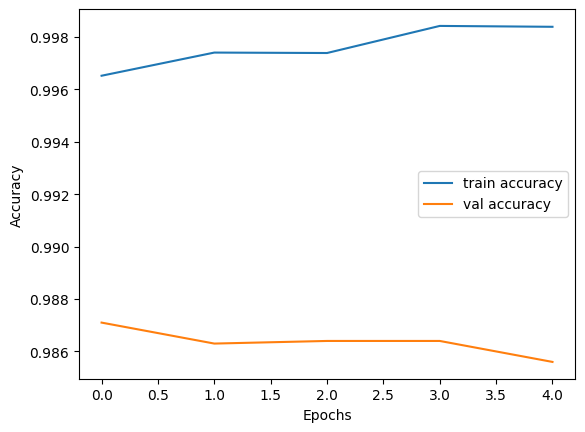

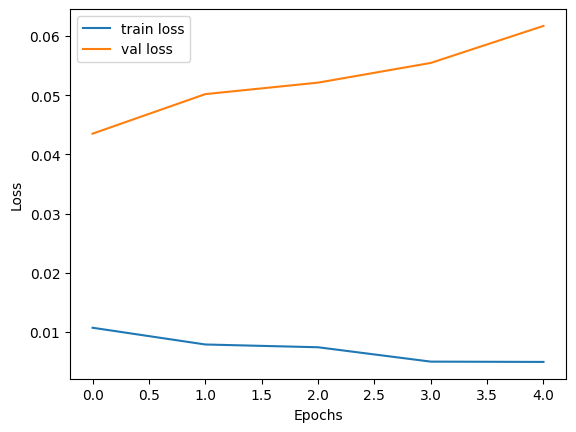

In [8]:
import matplotlib.pyplot as plt

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
import numpy as np

# Pick one test image
img = x_test[0].reshape(1,28,28,1)  # reshape for CNN
prediction = model.predict(img)
print("Predicted class:", np.argmax(prediction))
print("True class:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted class: 7
True class: 7


In [11]:
# Save in new Keras format
model.save("mnist_model.keras")

# Later, load it back
from tensorflow.keras.models import load_model
model = load_model("mnist_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [12]:
import numpy as np

# Pick one test image
img = x_test[0].reshape(1,28,28,1)   # reshape for CNN input
prediction = model.predict(img)

print("Predicted class:", np.argmax(prediction))
print("True class:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted class: 7
True class: 7


In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy after reloading:", test_acc)

313/313 - 2s - 6ms/step - accuracy: 0.9856 - loss: 0.0617
Test accuracy after reloading: 0.9855999946594238


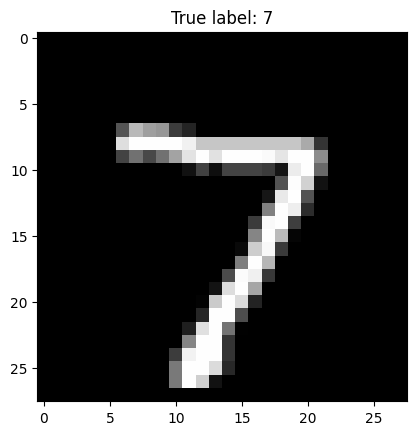

In [14]:
import matplotlib.pyplot as plt

plt.imshow(x_test[0].reshape(28,28), cmap="gray")
plt.title(f"True label: {y_test[0]}")
plt.show()

In [16]:
from google.colab import files
files.download("mnist_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>